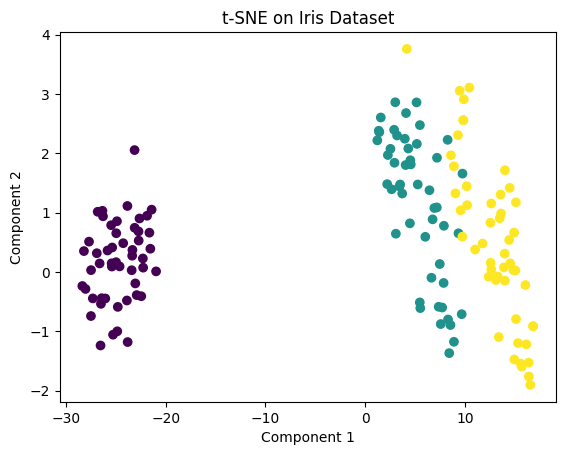

' Ankush Saha , 2341019012 , 51 '

In [1]:
# 1. Perform dimensionality reduction using scikit-learn’s TSNE estimator
# on the Iris dataset, then graph the results.

from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
labels = iris.target

tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X)

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels)
plt.title("t-SNE on Iris Dataset")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

''' Ankush Saha , 2341019012 , 51 '''

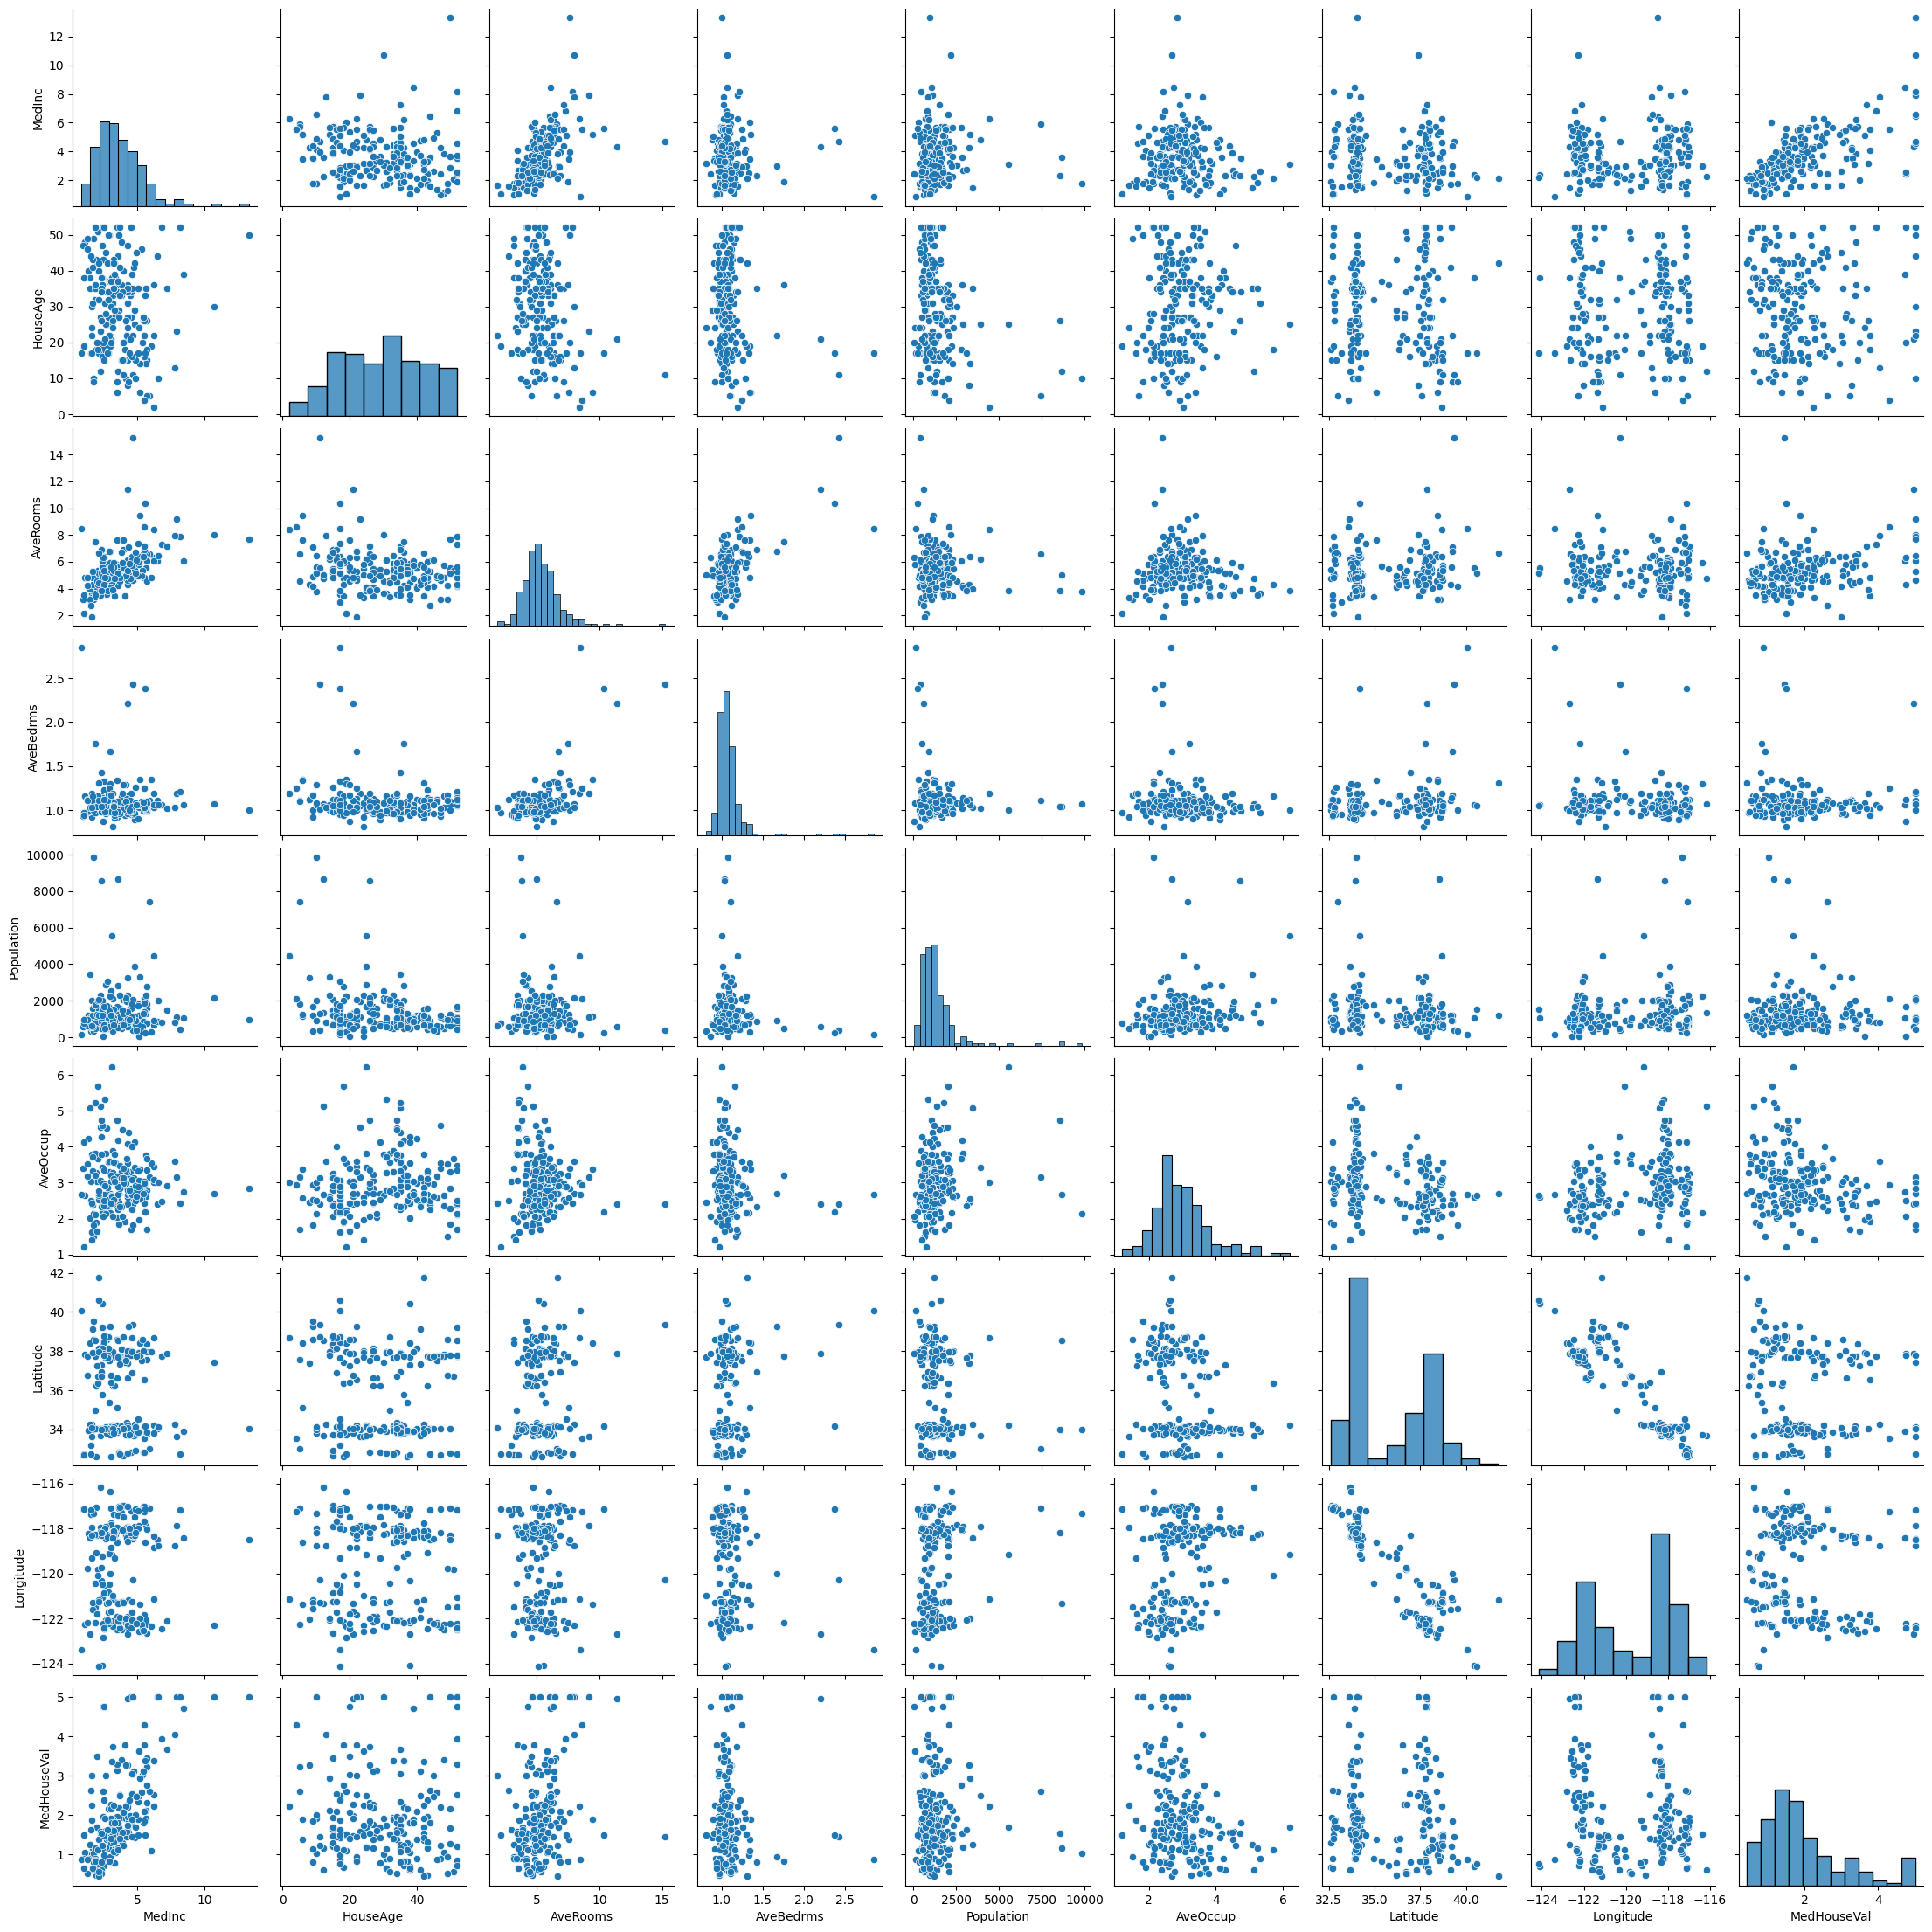

' Ankush Saha , 2341019012 , 51 '

In [ ]:
# 2. Create a Seaborn pairplot graph for the California Housing dataset.
# Try the Matplotlib features to pan and zoom in the diagram.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

sns.pairplot(df.sample(200))
plt.show()

''' Ankush Saha , 2341019012 , 51 '''

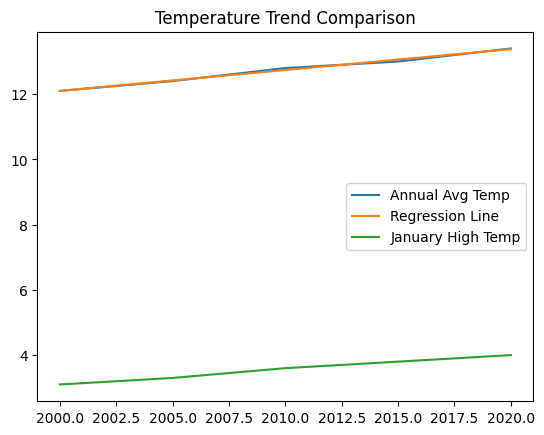

' Ankush Saha , 2341019012 , 51 '

In [4]:
# 3. Download NOAA NYC temperature dataset (1895–2025) and implement
# simple linear regression using average annual temperature data.
# Compare temperature trend with January high temperatures.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

years = np.array([2000, 2005, 2010, 2015, 2020]).reshape(-1, 1)
avg_temp = np.array([12.1, 12.4, 12.8, 13.0, 13.4])
jan_high = np.array([3.1, 3.3, 3.6, 3.8, 4.0])

model = LinearRegression()
model.fit(years, avg_temp)
predicted = model.predict(years)

plt.plot(years, avg_temp, label="Annual Avg Temp")
plt.plot(years, predicted, label="Regression Line")
plt.plot(years, jan_high, label="January High Temp")

plt.legend()
plt.title("Temperature Trend Comparison")
plt.show()

''' Ankush Saha , 2341019012 , 51 '''

In [5]:
# 4. Load the Iris dataset and perform classification using
# KNeighborsClassifier with default k. Print prediction accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

''' Ankush Saha , 2341019012 , 51 '''

Accuracy: 1.0


' Ankush Saha , 2341019012 , 51 '

In [6]:
# 5. Given dataset:
# A (2.0,3.0)->0
# B (1.0,1.0)->0
# C (4.0,4.0)->1
# D (5.0,2.0)->1
# Classify new point P(3.0,3.0) using Euclidean distance (KNN).

import math

points = {
    "A": ((2.0, 3.0), 0),
    "B": ((1.0, 1.0), 0),
    "C": ((4.0, 4.0), 1),
    "D": ((5.0, 2.0), 1),
}

P = (3.0, 3.0)

distances = []

for coord, label in points.values():
    dist = math.sqrt((coord[0]-P[0])**2 + (coord[1]-P[1])**2)
    distances.append((dist, label))

distances.sort()

k = 3
nearest = distances[:k]

classification = round(sum(label for _, label in nearest)/k)

print("Class of P:", classification)

''' Ankush Saha , 2341019012 , 51 '''

Class of P: 1


' Ankush Saha , 2341019012 , 51 '

In [7]:
# 6. Classify student (72,78,75) as Pass/Fail using KNN with k=3.

import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X = np.array([
    [85,90,88],
    [70,75,80],
    [60,65,70],
    [50,55,58],
    [95,92,96],
    [45,50,48]
])

y = np.array(["Pass","Pass","Fail","Fail","Pass","Fail"])

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

prediction = model.predict([[72,78,75]])

print("Prediction:", prediction[0])

''' Ankush Saha , 2341019012 , 51 '''

Prediction: Pass


' Ankush Saha , 2341019012 , 51 '

In [8]:
# 7. Use KFold and cross_val_score to determine optimal k
# for KNN classification on Iris dataset.

from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()

k_values = range(1, 11)
scores_mean = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, iris.data, iris.target, cv=kf)
    scores_mean.append(scores.mean())

optimal_k = k_values[scores_mean.index(max(scores_mean))]

print("Optimal k:", optimal_k)

''' Ankush Saha , 2341019012 , 51 '''

Optimal k: 4


' Ankush Saha , 2341019012 , 51 '

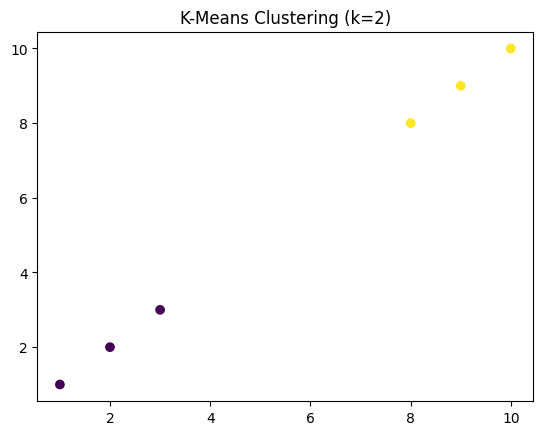

' Ankush Saha , 2341019012 , 51 '

In [9]:
# 8. Perform K-Means clustering on dataset
# {(1,1),(2,2),(3,3),(8,8),(9,9),(10,10)} using k=2 and visualize.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = np.array([(1,1),(2,2),(3,3),(8,8),(9,9),(10,10)])

model = KMeans(n_clusters=2, random_state=42)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("K-Means Clustering (k=2)")
plt.show()

''' Ankush Saha , 2341019012 , 51 '''

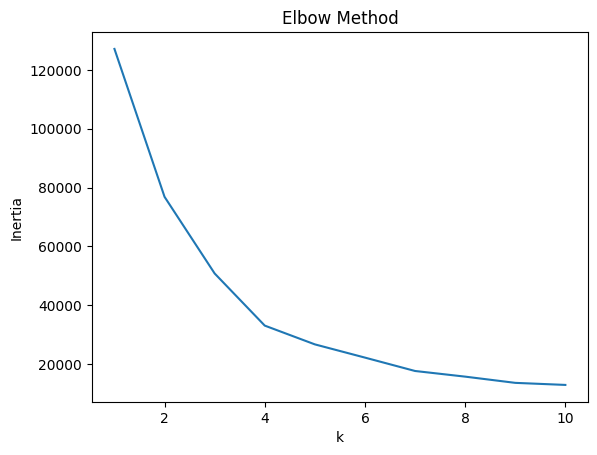

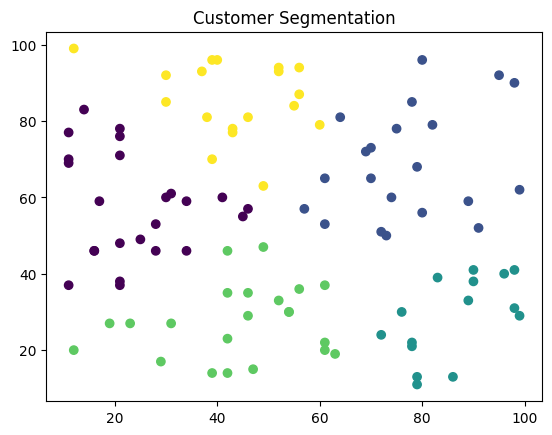

Insight: Clusters represent different spending behavior groups.


' Ankush Saha , 2341019012 , 51 '

In [10]:
# 9. Perform K-Means clustering on Mall Customer Segmentation dataset.
# Use k=5 and determine optimal k via Elbow Method.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = np.random.randint(10,100,(100,2))

inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(data)
    inertia.append(model.inertia_)

plt.plot(range(1,11), inertia)
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

model = KMeans(n_clusters=5, random_state=42)
labels = model.fit_predict(data)

plt.scatter(data[:,0], data[:,1], c=labels)
plt.title("Customer Segmentation")
plt.show()

print("Insight: Clusters represent different spending behavior groups.")

''' Ankush Saha , 2341019012 , 51 '''

In [11]:
# Question 10:
# (a) Create Series from [7,11,13,17]
# (b) Create Series with five elements all 100.0
# (c) Create Series with 20 random numbers (0–100) and show describe()
# (d) Create temperatures Series with custom indices
# (e) Create Series from dictionary formed in (d)

import pandas as pd
import numpy as np

s1 = pd.Series([7,11,13,17])
print(s1)

s2 = pd.Series([100.0]*5)
print(s2)

s3 = pd.Series(np.random.randint(0,101,20))
print(s3.describe())

temperatures = pd.Series(
    [98.6,98.9,100.2,97.9],
    index=["Julie","Charlie","Sam","Andrea"]
)

print(temperatures)

s4 = pd.Series(temperatures.to_dict())
print(s4)

''' Ankush Saha , 2341019012 , 51 '''

0     7
1    11
2    13
3    17
dtype: int64
0    100.0
1    100.0
2    100.0
3    100.0
4    100.0
dtype: float64
count     20.000000
mean      63.600000
std       31.984207
min        5.000000
25%       38.000000
50%       75.000000
75%       89.000000
max      100.000000
dtype: float64
Julie       98.6
Charlie     98.9
Sam        100.2
Andrea      97.9
dtype: float64
Julie       98.6
Charlie     98.9
Sam        100.2
Andrea      97.9
dtype: float64


' Ankush Saha , 2341019012 , 51 '